In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
TARGET_DRIVERS = ['ALB', 'LEC', 'NOR', 'RUS', 'VER']

TRACKS = [
    'Australia',
    'Saudi_Arabia',
    'Hungary',
    'Italy'
]

GROUP_COLS = ['Year', 'Track', 'Driver', 'Stint', 'Compound']

In [3]:
def load_and_filter_data(base_path='datasets'):
    all_files = glob.glob(os.path.join(base_path, '**', '*.csv'), recursive=True)
    df_list = []

    for file in all_files:
        try:
            parts = os.path.normpath(file).split(os.sep)
            track = parts[-2]

            # 🔥 Track filter
            if track not in TRACKS:
                continue

            year = int(parts[-1][:4])

            df = pd.read_csv(file, low_memory=False)
            df['Year'] = year
            df['Track'] = track

            df_list.append(df)

        except Exception as e:
            print(f"Failed: {file} -> {e}")

    if not df_list:
        return pd.DataFrame()

    df = pd.concat(df_list, ignore_index=True)

    print("Initial rows:", len(df))

    # Driver filter
    df = df[df['Driver'].isin(TARGET_DRIVERS)].copy()

    print("After driver filter:", len(df))

    return df


df_raw = load_and_filter_data()

Initial rows: 16805
After driver filter: 4300


In [4]:
def clean_data(df):
    if df.empty:
        return df
    
    df = df.copy()

    # Keep only clean, representative racing laps when possible
    if 'IsAccurate' in df.columns:
        df = df[df['IsAccurate'] == True].copy()

    if 'PitOutTime' in df.columns:
        df['PitOutTime'] = pd.to_datetime(df['PitOutTime'], errors='coerce')
        df = df[df['PitOutTime'].isna()].copy()

    if 'PitInTime' in df.columns:
        df['PitInTime'] = pd.to_datetime(df['PitInTime'], errors='coerce')
        df = df[df['PitInTime'].isna()].copy()

    if 'TrackStatus' in df.columns:
        df = df[df['TrackStatus'].astype(str).isin(['1', ''])].copy()

    # --- LapTime ---
    df['LapTime'] = df['LapTime'].astype(str).str.strip()
    df['LapTime_sec'] = pd.to_timedelta(df['LapTime'], errors='coerce').dt.total_seconds()

    print("Valid LapTime:", df['LapTime_sec'].notna().sum())

    df = df.dropna(subset=['LapTime_sec'])
    df = df[df['LapTime_sec'] > 0]

    # --- TyreLife ---
    df['TyreLife'] = pd.to_numeric(df['TyreLife'], errors='coerce')
    df = df.dropna(subset=['TyreLife'])

    # --- Compound ---
    df = df.dropna(subset=['Compound'])
    df['Compound'] = df['Compound'].astype(str).str.upper().str.strip()
    df = df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])].copy()

    return df.reset_index(drop=True)


df_clean = clean_data(df_raw)

print("Raw rows:", len(df_raw))
print("Clean rows:", len(df_clean))

Valid LapTime: 3643
Raw rows: 4300
Clean rows: 3484


In [5]:
def engineering_features(df):
    if df.empty:
        return df

    df = df.copy()

    df = df.sort_values(by=GROUP_COLS + ['LapNumber'])

    df['Initial_Life'] = df.groupby(GROUP_COLS)['TyreLife'].transform('min')
    df['Stint_Usage'] = df['TyreLife'] - df['Initial_Life']
    df['Stint_Max_Life'] = df.groupby(GROUP_COLS)['TyreLife'].transform('max')

    stint_life_lookup = (
        df[GROUP_COLS + ['Stint_Max_Life']]
        .drop_duplicates()
        .groupby(['Year', 'Track', 'Compound'])['Stint_Max_Life']
        .quantile(0.75)
        .reset_index()
        .rename(columns={'Stint_Max_Life': 'Expected_Max_Life'})
    )

    df = df.merge(stint_life_lookup, on=['Year', 'Track', 'Compound'], how='left')

    life_range = df['Expected_Max_Life'] - df['Initial_Life']

    df['degradation_stint_%'] = np.where(
        life_range > 0,
        (df['Stint_Usage'] / life_range) * 100,
        0
    )

    df['degradation_stint_%'] = df['degradation_stint_%'].clip(0, 100)

    return df


df_features = engineering_features(df_clean)

display(df_features.head())

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FastF1Generated,IsAccurate,Year,Track,LapTime_sec,Initial_Life,Stint_Usage,Stint_Max_Life,Expected_Max_Life,degradation_stint_%
0,0 days 01:15:22.803000,ALB,23,0 days 00:01:28.217000,7.0,1.0,NaT,NaT,0 days 00:00:31.117000,0 days 00:00:18.795000,...,False,True,2022,Australia,88.217,7.0,0.0,56.0,38.0,0.000000
1,0 days 01:16:49.795000,ALB,23,0 days 00:01:26.992000,8.0,1.0,NaT,NaT,0 days 00:00:30.383000,0 days 00:00:18.622000,...,False,True,2022,Australia,86.992,7.0,1.0,56.0,38.0,3.225806
2,0 days 01:18:16.545000,ALB,23,0 days 00:01:26.750000,9.0,1.0,NaT,NaT,0 days 00:00:30.616000,0 days 00:00:18.650000,...,False,True,2022,Australia,86.750,7.0,2.0,56.0,38.0,6.451613
3,0 days 01:19:42.254000,ALB,23,0 days 00:01:25.709000,10.0,1.0,NaT,NaT,0 days 00:00:29.928000,0 days 00:00:18.567000,...,False,True,2022,Australia,85.709,7.0,3.0,56.0,38.0,9.677419
4,0 days 01:21:09.467000,ALB,23,0 days 00:01:27.213000,11.0,1.0,NaT,NaT,0 days 00:00:29.775000,0 days 00:00:18.670000,...,False,True,2022,Australia,87.213,7.0,4.0,56.0,38.0,12.903226


In [6]:
features = [
    'TyreLife',
    'Initial_Life',
    'Stint_Usage',
    'Expected_Max_Life',
    'LapNumber',
    'Compound',
    'Track',
    'Year'
]

target = 'degradation_stint_%'

df_model = df_features.dropna(subset=features + [target]).copy()

# Remove zero-length stints
df_model = df_model[df_model['Stint_Usage'] >= 0]

# Encoding
le_comp = LabelEncoder()
df_model['Compound_Enc'] = le_comp.fit_transform(df_model['Compound'])

le_track = LabelEncoder()
df_model['Track_Enc'] = le_track.fit_transform(df_model['Track'])

X = df_model[
    ['TyreLife','Initial_Life','Stint_Usage','Expected_Max_Life','LapNumber','Compound_Enc','Track_Enc','Year']
]

y = df_model[target]

In [7]:
holdout_year = df_model['Year'].max()

train_mask = df_model['Year'] < holdout_year
test_mask = df_model['Year'] == holdout_year

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print(f"Train years: {sorted(df_model.loc[train_mask, 'Year'].unique())}")
print(f"Holdout year: {holdout_year}")
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

models = {
    'Ridge': Ridge(alpha=1.5),
    'RandomForest': RandomForestRegressor(
        n_estimators=220,
        max_depth=12,
        min_samples_leaf=3,
        min_samples_split=8,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=180,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=4,
        subsample=0.85,
        random_state=42
    )
}

model_scores = []
fitted_models = {}

for model_name, candidate_model in models.items():
    candidate_model.fit(X_train, y_train)
    candidate_pred = np.clip(candidate_model.predict(X_test), 0, 100)
    model_scores.append({
        'Model': model_name,
        'MAE': mean_absolute_error(y_test, candidate_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, candidate_pred)),
        'R2': r2_score(y_test, candidate_pred)
    })
    fitted_models[model_name] = {
        'model': candidate_model,
        'predictions': candidate_pred
    }

score_df = pd.DataFrame(model_scores).sort_values(['RMSE', 'MAE']).reset_index(drop=True)
best_model_name = score_df.iloc[0]['Model']
model = fitted_models[best_model_name]['model']
display(score_df)
print(f'Chosen model: {best_model_name}')

Train years: [2022, 2023, 2024]
Holdout year: 2025
Train rows: 2678, Test rows: 806


,Model,MAE,RMSE,R2
0,GradientBoosting,1.907004,4.155104,0.981218
1,Ridge,4.268634,7.646420,0.936395
2,RandomForest,5.462006,8.211629,0.926644


Chosen model: GradientBoosting


In [8]:
y_pred = np.clip(model.predict(X_test), 0, 100)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

results = df_model.loc[test_mask].copy()
results['Actual_Degradation'] = y_test
results['Predicted_Degradation'] = y_pred

display(results[
    ['Driver','Track','Compound','TyreLife','Actual_Degradation','Predicted_Degradation']
])

track_mae = (
    results.groupby('Track')
    .apply(lambda g: mean_absolute_error(g['Actual_Degradation'], g['Predicted_Degradation']))
    .reset_index(name='MAE')
    .sort_values('MAE')
    .reset_index(drop=True)
)

compound_mae = (
    results.groupby('Compound')
    .apply(lambda g: mean_absolute_error(g['Actual_Degradation'], g['Predicted_Degradation']))
    .reset_index(name='MAE')
    .sort_values('MAE')
    .reset_index(drop=True)
)

display(track_mae)
display(compound_mae)

MAE: 1.9070038028045215
RMSE: 4.155104479593704
R2: 0.9812181215704313


,Driver,Track,Compound,TyreLife,Actual_Degradation,Predicted_Degradation
2678,ALB,Australia,MEDIUM,9.0,0.000000,35.918521
2679,ALB,Australia,MEDIUM,10.0,100.000000,51.656496
2680,LEC,Australia,HARD,9.0,0.000000,17.414840
2681,LEC,Australia,HARD,10.0,40.000000,27.694824
2682,LEC,Australia,HARD,13.0,100.000000,53.570487
...,...,...,...,...,...,...
3479,VER,Saudi_Arabia,HARD,25.0,82.142857,84.765361
3480,VER,Saudi_Arabia,HARD,26.0,85.714286,87.137594
3481,VER,Saudi_Arabia,HARD,27.0,89.285714,88.623601
3482,VER,Saudi_Arabia,HARD,28.0,92.857143,91.132996


C:\Users\roshi\AppData\Local\Temp\ipykernel_7028\1852758534.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: mean_absolute_error(g['Actual_Degradation'], g['Predicted_Degradation']))
C:\Users\roshi\AppData\Local\Temp\ipykernel_7028\1852758534.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: mean_absolute_error(g['Actual_Degradation'], g['Predicted_Degradation']))


,Track,MAE
0,Hungary,1.157436
1,Saudi_Arabia,1.681867
2,Italy,2.176792
3,Australia,22.742140


,Compound,MAE
0,HARD,1.332365
1,MEDIUM,2.398404
2,SOFT,6.927111


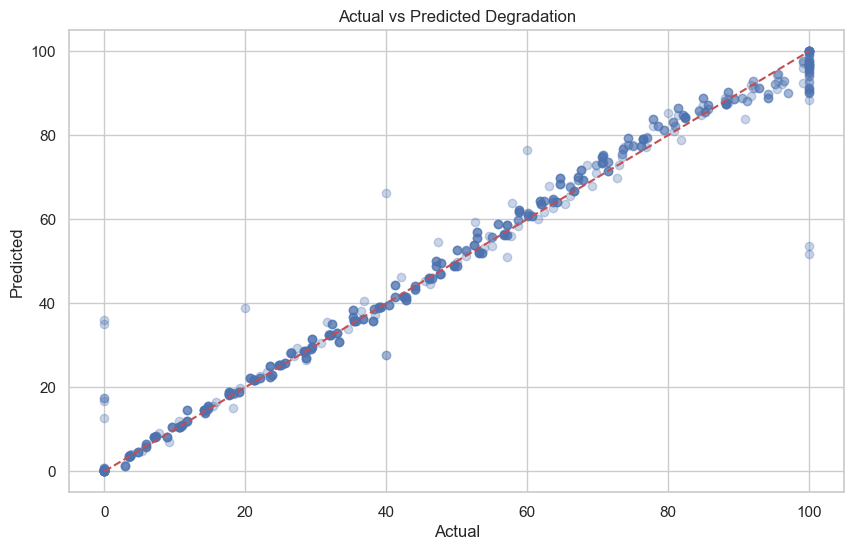

In [9]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0,100],[0,100],'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Degradation")
plt.show()

,Track,Compound,TyreLife,Expected_Max_Life,Actual_Degradation,Predicted_Degradation
0,Italy,SOFT,1,22.0,NaN,0.077795
1,Italy,SOFT,2,22.0,0.000000,5.453807
2,Italy,SOFT,3,22.0,5.000000,11.591640
3,Italy,SOFT,4,22.0,6.666667,15.934044
4,Italy,SOFT,5,22.0,14.259259,20.720848
5,Italy,SOFT,6,22.0,21.851852,25.279021
6,Italy,SOFT,7,22.0,29.444444,29.681787
7,Italy,SOFT,8,22.0,37.037037,32.588511
8,Italy,SOFT,9,22.0,44.629630,36.714062
9,Italy,SOFT,10,22.0,38.666667,41.842793


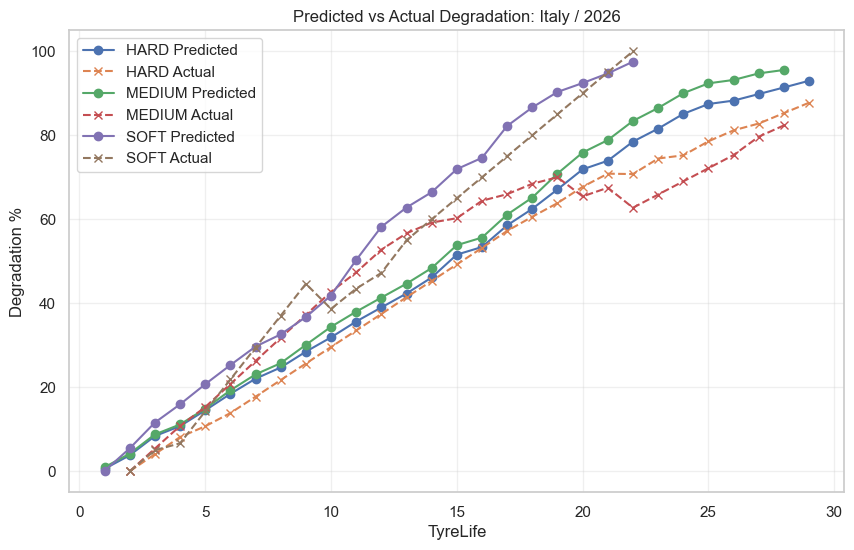

In [13]:
# -------------------------------
# 1. Fallback lookups
# -------------------------------
fallback_lookup = (
    df_features[['Track', 'Compound', 'Expected_Max_Life']]
    .dropna()
    .groupby(['Track', 'Compound'])['Expected_Max_Life']
    .median()
    .to_dict()
)

compound_fallback_lookup = (
    df_features[['Compound', 'Expected_Max_Life']]
    .dropna()
    .groupby('Compound')['Expected_Max_Life']
    .median()
    .to_dict()
)

actual_lookup = (
    df_features[['Track', 'Compound', 'TyreLife', 'degradation_stint_%']]
    .dropna()
    .groupby(['Track', 'Compound', 'TyreLife'], as_index=False)['degradation_stint_%']
    .mean()
    .rename(columns={'degradation_stint_%': 'Actual_Degradation'})
)

# -------------------------------
# 2. Prediction function
# -------------------------------
def predict_future_race_degradation(track, compound, year, initial_life=1):

    # -----------------------
    # Get expected max life
    # -----------------------
    key = (track, compound)
    expected_max_life = fallback_lookup.get(key)

    if expected_max_life is None or pd.isna(expected_max_life):
        expected_max_life = compound_fallback_lookup.get(compound)
        if expected_max_life is not None and not pd.isna(expected_max_life):
            print(f"Using compound-level fallback for {track} / {compound}: {expected_max_life:.2f}")

    if expected_max_life is None or pd.isna(expected_max_life):
        raise ValueError(f"No historical Expected_Max_Life found for compound {compound}")

    # -----------------------
    # Create scenario
    # -----------------------
    lap_count = max(1, int(round(expected_max_life - initial_life + 1)))

    tyre_life_values = np.arange(initial_life, initial_life + lap_count)
    lap_numbers = np.arange(1, lap_count + 1)

    scenario = pd.DataFrame({
        'TyreLife': tyre_life_values,
        'LapNumber': lap_numbers,
        'Compound': compound,
        'Track': track,
        'Year': year,
        'Initial_Life': initial_life   # ✅ FIXED
    })

    # -----------------------
    # Feature engineering (MATCH TRAINING)
    # -----------------------
    scenario['Stint'] = 1
    scenario['Driver'] = 'SIM'

    # REQUIRED FEATURES
    scenario['Stint_Usage'] = scenario['TyreLife'] - scenario['Initial_Life']
    scenario['Expected_Max_Life'] = expected_max_life

    # Stint features
    scenario['Stint_Lap'] = np.arange(1, len(scenario) + 1)
    scenario['Max_Stint_Lap'] = len(scenario)

    scenario['Stint_Progress'] = scenario['Stint_Lap'] / scenario['Max_Stint_Lap']
    scenario['TyreLife_norm'] = scenario['TyreLife'] / scenario['TyreLife'].max()

    # -----------------------
    # Encoding (MATCH TRAINING NAMES)
    # -----------------------
    scenario['Compound_Enc'] = le_comp.transform(scenario['Compound'])
    scenario['Track_Enc'] = le_track.transform(scenario['Track'])

    # If used in training:
    # scenario['Driver_Enc'] = le_driver.transform(['SIM'] * len(scenario))

    # -----------------------
    # SAFETY CHECK (IMPORTANT)
    # -----------------------
    missing_cols = [col for col in X.columns if col not in scenario.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in scenario: {missing_cols}")

    # -----------------------
    # Match EXACT features
    # -----------------------
    scenario_model = scenario[X.columns]

    # -----------------------
    # Predict
    # -----------------------
    scenario['Predicted_Degradation'] = np.clip(
        model.predict(scenario_model),
        0,
        100
    )

    scenario['Expected_Max_Life'] = round(float(expected_max_life), 2)

    return scenario


# -------------------------------
# 3. Run simulation
# -------------------------------
future_track = 'Italy'
future_year = int(df_model['Year'].max()) + 1
future_compounds = ['SOFT', 'MEDIUM', 'HARD']

future_predictions = []

for compound in future_compounds:

    if compound not in set(df_model['Compound'].unique()):
        print(f"Skipping {compound}: not present in training data")
        continue

    try:
        pred = predict_future_race_degradation(
            track=future_track,
            compound=compound,
            year=future_year,
            initial_life=1
        )
        future_predictions.append(pred)

    except ValueError as e:
        print(e)

if not future_predictions:
    raise ValueError('No compound predictions could be generated.')

# -------------------------------
# 4. Combine results
# -------------------------------
future_prediction_all = pd.concat(future_predictions, ignore_index=True)

future_prediction_all = future_prediction_all.merge(
    actual_lookup,
    on=['Track', 'Compound', 'TyreLife'],
    how='left'
)

# -------------------------------
# 5. Display
# -------------------------------
display(future_prediction_all[
    ['Track', 'Compound', 'TyreLife',
     'Expected_Max_Life',
     'Actual_Degradation',
     'Predicted_Degradation']
].head(30))

# -------------------------------
# 6. Plot
# -------------------------------
for compound, compound_df in future_prediction_all.groupby('Compound'):

    plt.plot(
        compound_df['TyreLife'],
        compound_df['Predicted_Degradation'],
        marker='o',
        label=f'{compound} Predicted'
    )

    actual_df = compound_df.dropna(subset=['Actual_Degradation'])

    if not actual_df.empty:
        plt.plot(
            actual_df['TyreLife'],
            actual_df['Actual_Degradation'],
            marker='x',
            linestyle='--',
            label=f'{compound} Actual'
        )

plt.xlabel('TyreLife')
plt.ylabel('Degradation %')
plt.title(f'Predicted vs Actual Degradation: {future_track} / {future_year}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()